# Layered Classifier for Yelp Star Rating Prediction

This script:
1. Loads cleaned Yelp review datasets from 'cleaned-data/'.
2. Vectorizes review text at each stage using separate TF-IDF models.
3. Trains a first-stage Logistic Regression classifier for sentiment (negative, neutral, positive).
4. Routes negative and positive predictions to specialized Logistic Regression models (1/2 stars and 4/5 stars, respectively).
5. Assigns 3 stars if neutral.
6. Outputs evaluation metrics and confusion matrices.

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [14]:
def load_data():

    folder = "../Preprocessing-FeatureExtraction/cleaned-data/"
    csv_files = glob.glob(os.path.join(folder, "*.csv"))
    
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        df['state'] = os.path.splitext(os.path.basename(file))[0]
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    df = data.dropna()
    
    # Create sentiment labels: 0=negative (1-2), 1=neutral (3), 2=positive (4-5)
    df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))
    
    print(f"Loaded {len(df)} reviews from {len(dfs)} states.")
    return df

In [15]:
class LayeredStarClassifier:
    """
    Three-stage hierarchical classifier:
    Stage 1: Classify sentiment (negative/neutral/positive)
    Stage 2a: For negative reviews, classify as 1 or 2 stars
    Stage 2b: For positive reviews, classify as 4 or 5 stars
    Stage 3: Neutral reviews automatically assigned 3 stars
    """
    
    def __init__(self, max_features=10000, ngram_range=(1, 2)):
    
        # Stage 1: Sentiment classifier (negative/neutral/positive)
        self.sentiment_classifier = LogisticRegression(max_iter=1000, random_state=42)
        
        # Stage 2a: Negative rating classifier (1 vs 2 stars)
        self.negative_classifier = LogisticRegression(max_iter=1000, random_state=42)
        
        # Stage 2b: Positive rating classifier (4 vs 5 stars)
        self.positive_classifier = LogisticRegression(max_iter=1000, random_state=42)
        
        # Vectorizers for each stage
        self.sentiment_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.negative_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.positive_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        
        self.max_features = max_features
        self.ngram_range = ngram_range

    def fit(self, X_train, y_train):
        """
        Train all three stages of the classifier
        
        Args:
            X_train: Training text data (pandas Series or array of strings)
            y_train: Training star ratings (1-5)
        """
        print("\n" + "="*60)
        print("TRAINING LAYERED CLASSIFIER")
        print("="*60)
        
        # Convert to pandas Series if needed
        if not isinstance(X_train, pd.Series):
            X_train = pd.Series(X_train)
        if not isinstance(y_train, pd.Series):
            y_train = pd.Series(y_train)
        
        # Create sentiment labels from star ratings
        sentiment_labels = y_train.apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))
        
        # ====================================================================
        # STAGE 1: Train sentiment classifier (negative/neutral/positive)
        # ====================================================================
        print("\nStage 1: Training sentiment classifier (negative/neutral/positive)...")
        X_train_sentiment = self.sentiment_vectorizer.fit_transform(X_train)
        self.sentiment_classifier.fit(X_train_sentiment, sentiment_labels)
        
        # Report sentiment classifier performance on training data
        sentiment_pred = self.sentiment_classifier.predict(X_train_sentiment)
        sentiment_acc = accuracy_score(sentiment_labels, sentiment_pred)
        print(f"  Sentiment classifier training accuracy: {sentiment_acc:.4f}")
        
        # ====================================================================
        # STAGE 2a: Train negative classifier (1 vs 2 stars)
        # ====================================================================
        print("\nStage 2a: Training negative classifier (1 vs 2 stars)...")
        negative_mask = y_train.isin([1, 2])
        X_train_negative = X_train[negative_mask]
        y_train_negative = y_train[negative_mask]
        
        if len(X_train_negative) > 0:
            X_train_negative_tfidf = self.negative_vectorizer.fit_transform(X_train_negative)
            self.negative_classifier.fit(X_train_negative_tfidf, y_train_negative)
            
            negative_pred = self.negative_classifier.predict(X_train_negative_tfidf)
            negative_acc = accuracy_score(y_train_negative, negative_pred)
            print(f"  Negative classifier training accuracy: {negative_acc:.4f}")
            print(f"  Training samples: {len(X_train_negative)}")
        else:
            print("  WARNING: No negative samples in training data!")
        
        # ====================================================================
        # STAGE 2b: Train positive classifier (4 vs 5 stars)
        # ====================================================================
        print("\nStage 2b: Training positive classifier (4 vs 5 stars)...")
        positive_mask = y_train.isin([4, 5])
        X_train_positive = X_train[positive_mask]
        y_train_positive = y_train[positive_mask]
        
        if len(X_train_positive) > 0:
            X_train_positive_tfidf = self.positive_vectorizer.fit_transform(X_train_positive)
            self.positive_classifier.fit(X_train_positive_tfidf, y_train_positive)
            
            positive_pred = self.positive_classifier.predict(X_train_positive_tfidf)
            positive_acc = accuracy_score(y_train_positive, positive_pred)
            print(f"  Positive classifier training accuracy: {positive_acc:.4f}")
            print(f"  Training samples: {len(X_train_positive)}")
        else:
            print("  WARNING: No positive samples in training data!")
        
        print("\n" + "="*60)
        print("LAYERED CLASSIFIER TRAINING COMPLETE")
        print("="*60)
        
        return self
    
    def predict(self, X_test):
        """
        Predict star ratings using the layered classifier
        
        Args:
            X_test: Test text data (pandas Series or array of strings)
            
        Returns:
            Predicted star ratings (1-5)
        """
        # Convert to pandas Series if needed
        if not isinstance(X_test, pd.Series):
            X_test = pd.Series(X_test)
        
        # Initialize predictions array
        predictions = np.zeros(len(X_test), dtype=int)
        
        # ====================================================================
        # STAGE 1: Predict sentiment
        # ====================================================================
        X_test_sentiment = self.sentiment_vectorizer.transform(X_test)
        sentiment_pred = self.sentiment_classifier.predict(X_test_sentiment)
        
        # ====================================================================
        # STAGE 2a: For negative sentiment, predict 1 vs 2
        # ====================================================================
        negative_mask = sentiment_pred == 0
        if negative_mask.sum() > 0:
            X_test_negative = X_test[negative_mask]
            X_test_negative_tfidf = self.negative_vectorizer.transform(X_test_negative)
            predictions[negative_mask] = self.negative_classifier.predict(X_test_negative_tfidf)
        
        # ====================================================================
        # STAGE 2b: For positive sentiment, predict 4 vs 5
        # ====================================================================
        positive_mask = sentiment_pred == 2
        if positive_mask.sum() > 0:
            X_test_positive = X_test[positive_mask]
            X_test_positive_tfidf = self.positive_vectorizer.transform(X_test_positive)
            predictions[positive_mask] = self.positive_classifier.predict(X_test_positive_tfidf)
        
        # ====================================================================
        # STAGE 3: For neutral sentiment, assign 3 stars
        # ====================================================================
        neutral_mask = sentiment_pred == 1
        predictions[neutral_mask] = 3
        
        return predictions
    
    def predict_proba(self, X_test):
        """
        Predict probability distributions for star ratings
            
        Returns:
            Array of shape (n_samples, 5) with probabilities for each star rating
        """
        if not isinstance(X_test, pd.Series):
            X_test = pd.Series(X_test)
        
        # Initialize probability array (5 classes: 1-5 stars)
        proba = np.zeros((len(X_test), 5))
        
        # Get sentiment predictions and probabilities
        X_test_sentiment = self.sentiment_vectorizer.transform(X_test)
        sentiment_proba = self.sentiment_classifier.predict_proba(X_test_sentiment)
        sentiment_pred = self.sentiment_classifier.predict(X_test_sentiment)
        
        # For negative sentiment
        negative_mask = sentiment_pred == 0
        if negative_mask.sum() > 0:
            X_test_negative = X_test[negative_mask]
            X_test_negative_tfidf = self.negative_vectorizer.transform(X_test_negative)
            negative_proba = self.negative_classifier.predict_proba(X_test_negative_tfidf)
            proba[negative_mask, 0] = negative_proba[:, 0] * sentiment_proba[negative_mask, 0]
            proba[negative_mask, 1] = negative_proba[:, 1] * sentiment_proba[negative_mask, 0]
        
        # For neutral sentiment
        neutral_mask = sentiment_pred == 1
        proba[neutral_mask, 2] = sentiment_proba[neutral_mask, 1]
        
        # For positive sentiment
        positive_mask = sentiment_pred == 2
        if positive_mask.sum() > 0:
            X_test_positive = X_test[positive_mask]
            X_test_positive_tfidf = self.positive_vectorizer.transform(X_test_positive)
            positive_proba = self.positive_classifier.predict_proba(X_test_positive_tfidf)
            proba[positive_mask, 3] = positive_proba[:, 0] * sentiment_proba[positive_mask, 2]
            proba[positive_mask, 4] = positive_proba[:, 1] * sentiment_proba[positive_mask, 2]
        
        return proba

In [16]:
def evaluate_classifier(y_true, y_pred, classifier_name="Classifier"):
    """Evaluate and print classifier performance"""
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n{classifier_name} Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Macro-F1: {macro_f1:.4f}")
    
    print("\nPer-Class Performance:")
    report = classification_report(y_true, y_pred, labels=[1, 2, 3, 4, 5], output_dict=True)
    for star in [1, 2, 3, 4, 5]:
        if str(star) in report:
            print(f"  {star} stars - Precision: {report[str(star)]['precision']:.4f}, "
                  f"Recall: {report[str(star)]['recall']:.4f}, "
                  f"F1: {report[str(star)]['f1-score']:.4f}")
    
    return accuracy, macro_f1, report


In [17]:
def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[1, 2, 3, 4, 5],
                yticklabels=[1, 2, 3, 4, 5])
    plt.title(title, fontsize=16)
    plt.ylabel('True Star Rating', fontsize=12)
    plt.xlabel('Predicted Star Rating', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/cl/5mfvhcls2nv2h9gy15m04b640000gn/T/ipykernel_84654/2893345601.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))


Loaded 5222860 reviews from 20 states.
LAYERED STAR RATING CLASSIFIER

Sampling 500000 reviews...

Class distribution in sample:
stars
1.0     60548
2.0     41858
3.0     56055
4.0    118923
5.0    222616
Name: count, dtype: int64

Training set: 450000 reviews
Test set: 50000 reviews

TRAINING LAYERED CLASSIFIER

Stage 1: Training sentiment classifier (negative/neutral/positive)...
  Sentiment classifier training accuracy: 0.8864

Stage 2a: Training negative classifier (1 vs 2 stars)...
  Negative classifier training accuracy: 0.8020
  Training samples: 92165

Stage 2b: Training positive classifier (4 vs 5 stars)...
  Positive classifier training accuracy: 0.7845
  Training samples: 307385

LAYERED CLASSIFIER TRAINING COMPLETE

Making predictions on test set...

Layered Classifier Results:
  Accuracy: 0.6811
  Macro-F1: 0.5996

Per-Class Performance:
  1 stars - Precision: 0.7257, Recall: 0.8226, F1: 0.7711
  2 stars - Precision: 0.4782, Recall: 0.4214, F1: 0.4480
  3 stars - Precision

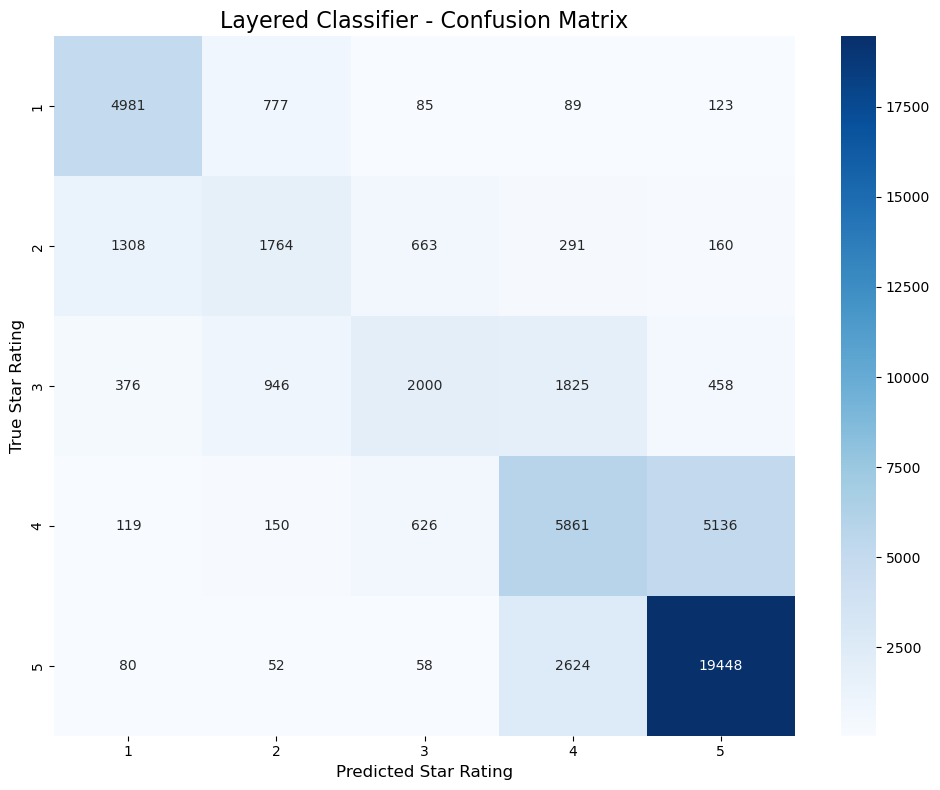


COMPARISON WITH BASELINE LOGISTIC REGRESSION

Baseline Logistic Regression Results:
  Accuracy: 0.6789
  Macro-F1: 0.5967

Per-Class Performance:
  1 stars - Precision: 0.7244, Recall: 0.8157, F1: 0.7673
  2 stars - Precision: 0.4923, Recall: 0.3607, F1: 0.4164
  3 stars - Precision: 0.5244, Recall: 0.4243, F1: 0.4690
  4 stars - Precision: 0.5545, Recall: 0.4797, F1: 0.5144
  5 stars - Precision: 0.7675, Recall: 0.8719, F1: 0.8164


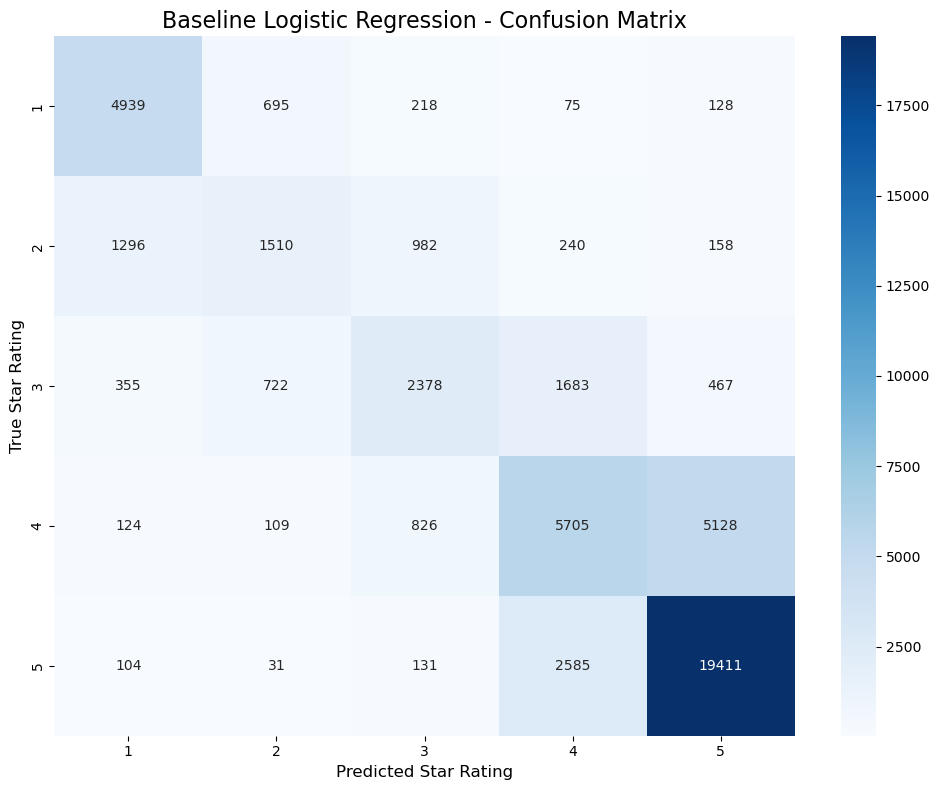


FINAL COMPARISON
Metric                         Layered         Baseline        Difference     
------------------------------------------------------------
Accuracy                       0.6811          0.6789          +0.0022
Macro-F1                       0.5996          0.5967          +0.0029


In [18]:
def main(data, n=500000):
    """
    Main function to train and evaluate layered classifier
    
    Args:
        data: Full dataset
        n: Sample size to use
    """
    print("="*60)
    print("LAYERED STAR RATING CLASSIFIER")
    print("="*60)
    
    # Sample data
    print(f"\nSampling {n} reviews...")
    data_sample = data.sample(n=min(n, len(data)), random_state=42)
    
    print(f"\nClass distribution in sample:")
    print(data_sample['stars'].value_counts().sort_index())
    
    # Prepare features and labels
    X = data_sample['clean_text']
    y = data_sample['stars'].astype(int)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {len(X_train)} reviews")
    print(f"Test set: {len(X_test)} reviews")
    
    # Initialize and train layered classifier
    layered_clf = LayeredStarClassifier(max_features=10000, ngram_range=(1, 2))
    layered_clf.fit(X_train, y_train)
    
    # Make predictions
    print("\nMaking predictions on test set...")
    y_pred = layered_clf.predict(X_test)
    
    # Evaluate
    accuracy, macro_f1, report = evaluate_classifier(
        y_test, y_pred, 
        classifier_name="Layered Classifier"
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(
        y_test, y_pred,
        title="Layered Classifier - Confusion Matrix",
        save_path="layered_classifier_confusion_matrix.png"
    )
    
    # Compare with baseline (optional)
    print("\n" + "="*60)
    print("COMPARISON WITH BASELINE LOGISTIC REGRESSION")
    print("="*60)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    baseline = LogisticRegression(max_iter=1000, random_state=42)
    baseline.fit(X_train_tfidf, y_train)
    y_pred_baseline = baseline.predict(X_test_tfidf)
    
    baseline_accuracy, baseline_f1, baseline_report = evaluate_classifier(
        y_test, y_pred_baseline,
        classifier_name="Baseline Logistic Regression"
    )
    
    plot_confusion_matrix(
        y_test, y_pred_baseline,
        title="Baseline Logistic Regression - Confusion Matrix",
        save_path="baseline_confusion_matrix.png"
    )
    
    # Summary comparison
    print("\n" + "="*60)
    print("FINAL COMPARISON")
    print("="*60)
    print(f"{'Metric':<30} {'Layered':<15} {'Baseline':<15} {'Difference':<15}")
    print("-"*60)
    print(f"{'Accuracy':<30} {accuracy:<15.4f} {baseline_accuracy:<15.4f} {accuracy - baseline_accuracy:+.4f}")
    print(f"{'Macro-F1':<30} {macro_f1:<15.4f} {baseline_f1:<15.4f} {macro_f1 - baseline_f1:+.4f}")
    
    return layered_clf, report, baseline_report

# ============================================================================
# 5. RUN
# ============================================================================

if __name__ == "__main__":
    # Load data
    df = load_data()
    
    # Train and evaluate
    layered_clf, layered_report, baseline_report = main(df, n=500000)

/var/folders/cl/5mfvhcls2nv2h9gy15m04b640000gn/T/ipykernel_84654/2893345601.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))


Loaded 5222860 reviews from 20 states.
LAYERED STAR RATING CLASSIFIER

Sampling 500000 reviews...

Class distribution in sample:
stars
1.0     60548
2.0     41858
3.0     56055
4.0    118923
5.0    222616
Name: count, dtype: int64

Training set: 450000 reviews
Test set: 50000 reviews

TRAINING LAYERED CLASSIFIER

Stage 1: Training sentiment classifier (negative/neutral/positive)...
  Sentiment classifier training accuracy: 0.8864

Stage 2a: Training negative classifier (1 vs 2 stars)...
  Negative classifier training accuracy: 0.8020
  Training samples: 92165

Stage 2b: Training positive classifier (4 vs 5 stars)...
  Positive classifier training accuracy: 0.7845
  Training samples: 307385

LAYERED CLASSIFIER TRAINING COMPLETE

Making predictions on test set...

Layered Classifier Results:
  Accuracy: 0.6811
  Macro-F1: 0.5996

Per-Class Performance:
  1 stars - Precision: 0.7257, Recall: 0.8226, F1: 0.7711
  2 stars - Precision: 0.4782, Recall: 0.4214, F1: 0.4480
  3 stars - Precision

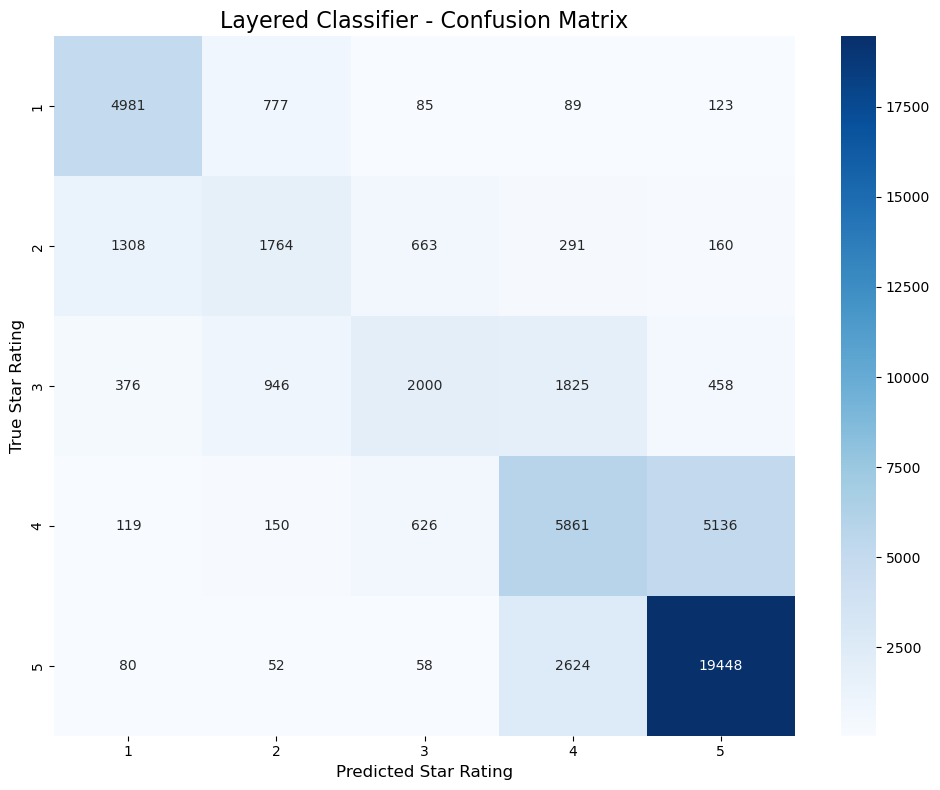


COMPARISON WITH BASELINE LOGISTIC REGRESSION


In [19]:
df = load_data()
layered_clf, layered_report, baseline_report = main(df, n=500000)